In [1]:
import pymupdf
import re
import json
import urllib.request
import textwrap
from tqdm import tqdm
from kiwipiepy import Kiwi
import matplotlib.pyplot as plt
from matplotlib import font_manager
import seaborn as sns
import random

## 1. Load PDF

In [4]:
# -----------------------------
# 1. PDF 로드 (layout 유지)
# -----------------------------

def parse_pdf_to_chunks(path):
    # fitz.open(path) 대신 pymupdf.open(path) 사용 가능
    doc = pymupdf.open(path)
    chunks = []
    current_chunk = None
    
    # 설정 상수화
    HEADER_LIMIT = 80  
    FOOTER_LIMIT = 700

    for page_num in tqdm(range(len(doc)), desc="PDF 페이지 처리 중"):
        page = doc[page_num]
        # "dict" 옵션을 통해 폰트, 크기, 좌표 정보를 모두 가져옴
        blocks = page.get_text("dict")["blocks"]
        # y좌표(bbox[1]) 기준으로 정렬하여 읽기 순서 보장
        blocks.sort(key=lambda b: b["bbox"][1])
        
        for block in blocks:
            # 0: 텍스트 블록, 1: 이미지 블록
            if block["type"] != 0 or "lines" not in block:
                continue
            
            # 상하단 여백 필터링
            block_y0, block_y1 = block["bbox"][1], block["bbox"][3]
            if block_y0 < HEADER_LIMIT or block_y1 > FOOTER_LIMIT:
                continue
                
            for line in block["lines"]:
                line_text = "".join([span["text"] for span in line["spans"]]).strip()
                if not line_text: 
                    continue

                # 첫 번째 span의 정보를 기준으로 스타일 판별
                sample_span = line["spans"][0]
                
                # 1. 스타일 조건: Bold체이거나 글자 크기가 큰 경우
                is_bold = "Bold" in sample_span.get("font", "")
                is_large = sample_span.get("size", 0) > 11.0
                style_cond = is_bold or is_large
                
                # 2. 내용 조건: 유효한 문자가 포함되어 있고 특정 키워드 제외
                has_content = re.search(r'[가-힣a-zA-Z]', line_text) is not None
                content_cond = has_content and len(line_text) > 1
                
                is_title = style_cond and content_cond and "연관검색어" not in line_text
                
                if is_title:
                    if current_chunk:
                        chunks.append(current_chunk)
                    
                    current_chunk = {
                        "용어": line_text,
                        "설명": "",
                        "metadata": {
                            "source": path,
                            "page": page_num + 1,
                            "연관검색어": []
                        }
                    }
                elif current_chunk:
                    if "연관검색어" in line_text:
                        match = re.search(r'연관검색어\s*:\s*(.*)', line_text)
                        if match:
                            related_text = match.group(1).strip()
                            keywords = re.split(r'[,/]', related_text)
                            current_chunk["metadata"]["연관검색어"] = [k.strip() for k in keywords if k.strip()]
                    else:
                        # 유의미한 텍스트(한글, 영문, 숫자)가 있을 때만 설명에 추가
                        if re.search(r'[가-힣a-zA-Z0-9]', line_text):
                            current_chunk["설명"] += line_text + " "

    if current_chunk:
        chunks.append(current_chunk)
        
    return chunks

In [6]:
file_path = "data/"
urllib.request.urlretrieve("https://github.com/chatgpt-kr/openai-api-tutorial/raw/main/ch07/2020_%EA%B2%BD%EC%A0%9C%EA%B8%88%EC%9C%B5%EC%9A%A9%EC%96%B4%20700%EC%84%A0_%EA%B2%8C%EC%8B%9C.pdf",
                           filename = file_path + "2020_경제금융용어 700선_게시.pdf")

('data/2020_경제금융용어 700선_게시.pdf', <http.client.HTTPMessage at 0x1fe87af7990>)

In [7]:
pdf_path = file_path + "2020_경제금융용어 700선_게시.pdf"
raw_chunks = parse_pdf_to_chunks(pdf_path)

# JSON 결과 예시 출력
print("청크 개수:", len(raw_chunks))
print(json.dumps(raw_chunks[10:15], ensure_ascii=False, indent=4))

PDF 페이지 처리 중: 100%|██████████| 371/371 [00:03<00:00, 117.07it/s]

청크 개수: 707
[
    {
        "용어": "가교은행",
        "설명": "청산 대상 금융기관의 자산, 부채를 임시로 넘겨받아 예금, 출금 등의 업무를 대행하고 합병, 채권채무관계 조정 등 후속조치를 수행하는 은행을 말한다. 금융기관이 파산한 경우 예금보험제도는 청산, 매각, 자산부채승계, 가교은행을 통한 인수 등의 수단을 통해 부실 금융기관을 처리한다. 이 중 가교은행을 통한 인수방식은 파산은행의 처리에 상당한 시간이 소요될 것으로 예상할 경우 사용되며 새로운 은행을 설립하여 자산, 부채를 포괄승계하도록 하고, 인수 희망자를 물색하는 등의 조치를 취하게 된다. 가교은행을 이용한 처리방식은 금융기관 파산에 따른 충격을 완화하고 시간적인 여유를 확보할 수 있는 것이 장점이다. 임무를 마치면 정리대상 금융기관과 마찬가지로 없어지는 한시적 기관이다. ",
        "metadata": {
            "source": "data/2020_경제금융용어 700선_게시.pdf",
            "page": 20,
            "연관검색어": []
        }
    },
    {
        "용어": "가동률",
        "설명": "생산능력 대비 생산실적의 백분율(생산실적/생산능력×100)로, 생산설비가 어느 정도 이용되는지를 나타내는 경제지표이다. 여기서 생산능력이란 사업체가 정상적인 설비, 인력, 조업시간 등 조업환경 하에서 생산할 때 최대 생산 가능량(적정생산능력)을 의미한 다. 생산설비의 가동상황인 가동률은 경기의 단면을 보여주는 좋은 지표가 될 수 있는데 이는 기업들이 앞으로의 경기 예상에 따라 가동률을 높이거나 낮추는 방법으로 생산량을 조절하기 때문이다. 다만 가동률이 높다고 무조건 좋은 것은 아닌데, 이는 경기가 침체된 상황에서 높은 가동률은 앞으로 경기가 회복될 것이라는 희망적인 신호로 인식되지만 경기가 활황세인 상황에서 지나치게 높은 가동률은 오히려 인플레이션 우려를 크게 하기 때

## 2. Data Pre-process

### 중복 체크

In [8]:
# 청크 중복 체크
extracted_terms = [chunk["용어"] for chunk in raw_chunks]
print("전체 청크 개수:", len(extracted_terms))

unique_terms = set(extracted_terms)
print("중복 제거 후 청크 개수:", len(unique_terms))

전체 청크 개수: 707
중복 제거 후 청크 개수: 706


In [9]:
from collections import Counter

# `extracted_terms` 리스트에 있는 각 용어의 빈도를 계산
# 예: ['a', 'b', 'a'] -> Counter({'a': 2, 'b': 1})
term_counts = Counter(extracted_terms)

# 빈도수가 1보다 큰 (즉, 2번 이상 나타나는) 중복 용어만 추출
duplicated = [term for term, count in term_counts.items() if count > 1]
print(duplicated)

['ABC']


In [10]:
for chunk in raw_chunks:
    if chunk["용어"] == "ABC":
        print(json.dumps(chunk, ensure_ascii=False, indent=4))

{
    "용어": "ABC",
    "설명": "VIX ・・・・・・・・・・・・・・・・・・・・・・・・・・・・・・・・・・・・・・・・・・・・・・・・・・・・・・・352 Beyond GDP ・・・・・・・・・・・・・・・・・・・・・・・・・・・・・・・・・・・・・・337 BIS 자기자본비율・・・・・・・・・・・・・・・・・・・・・・・・・・・・・・・338 CAMEL-R시스템/ROCA시스템/ CACREL시스템・・・・・・・・・・・・・・・・・・・・・・・・・・・・・・・338 CLS은행・・・・・・・・・・・・・・・・・・・・・・・・・・・・・・・・・・・・・・・・・・・・・・339 CMO ・・・・・・・・・・・・・・・・・・・・・・・・・・・・・・・・・・・・・・・・・・・・・・・・・・・・339 DebtRank ・・・・・・・・・・・・・・・・・・・・・・・・・・・・・・・・・・・・・・・・・・・340 EC방식・・・・・・・・・・・・・・・・・・・・・・・・・・・・・・・・・・・・・・・・・・・・・・・・340 FTSE 지수・・・・・・・・・・・・・・・・・・・・・・・・・・・・・・・・・・・・・・・・・・341 G2(Group of Two) ・・・・・・・・・・・・・・・・・・・・・・・・・・・341 G20(Group of 20) ・・・・・・・・・・・・・・・・・・・・・・・・・・・・342 G7(Group of Seven) ・・・・・・・・・・・・・・・・・・・・・・・・342 GDP갭・・・・・・・・・・・・・・・・・・・・・・・・・・・・・・・・・・・・・・・・・・・・・・・・・343 GDP디플레이터・・・・・・・・・・・・・・・・・・・・・・・・・・・・・・・・・・・343 Herstatt 리스크・・・・・・・・・・・・・・・・・・・・・・・・・・・・・・・・・344 IC 카드・・・・・・・・・・・・・・・・・・・・・・・・・・・・・・・・・・・・・・・・・・・・・・・・344 IMF 스탠드바이협약・・・・・・・・・・・・・・・・・・・・・・・・・・・345 IMF 쿼타・・・・・・・・・・・・・・・・・・・・・・・・・・・・・・・・・・・・・・・・・・・・・345 IMF 포지션・・・・・・・

In [11]:
# 용어의 길이가 2자 이하인 것들만 골라보기 (잘못 청킹된 노이즈 확인용)
noise_check = [t for t in unique_terms if len(t) <= 2]
print(f"의심되는 짧은 용어들: {noise_check}")

의심되는 짧은 용어들: ['국채', '청산', '잠상', '옵션', '결제', '추심', '스왑', '은선', '지급', '경기', '펀드', '모집']


### 누락된 용어 체크

In [12]:
# 특정 용어가 청크에 있는지 검색
def search_term(term_name, chunks):
    # chunks는 [{...}, {...}] 형태의 딕셔너리 리스트여야 함
    found = [c for c in chunks if term_name in c["용어"]]
    
    if found:
        for f in found:
            print(f"\n[찾음] 용어: {f['용어']} (Page: {f['metadata']['page']})")
            # print(f"설명 앞부분: {f['설명'][:100].strip()}...")
            print(textwrap.fill(f['설명'], width=120))
    else:
        print(f"\n[없음] '{term_name}'을(를) 찾을 수 없습니다.")

In [13]:
# 목차 기준 첫번째, 마지막 단어 체크
print(search_term("가계부실위험지수(HDRI)", raw_chunks))
print(search_term("VIX", raw_chunks))


[찾음] 용어: 가계부실위험지수(HDRI) (Page: 18)
가구의 소득 흐름은 물론 금융 및 실물 자산까지 종합적으로 고려하여 가계부채의 부실위험을 평가하는 지표로, 가계의 채무상환능력을 소득 측면에서 평가하는 원리금상 환비율(DSR; Debt Service Ratio)과
자산 측면에서 평가하는 부채/자산비율(DTA; Debt To Asset Ratio)을 결합하여 산출한 지수이다. 가계부실위험지수는 가구의 DSR과 DTA가 각각 40%, 100%일 때 100의 값을 갖도록 설정되어
있으며, 동 지수가 100을 초과하는 가구를 ‘위험가구’로 분류한다. 위험가구는 소득 및 자산 측면에서 모두 취약한 ‘고위험가구’, 자산 측면에서 취약한 ‘고DTA가구’, 소득 측면에서 취약한 ‘고DSR가구’로
구분할 수 있다. 다만 위험 및 고위험 가구는 가구의 채무상환능력 취약성 정도를 평가하기 위한 것이며 이들 가구가 당장 채무상환 불이행, 즉 임계상황에 직면한 것을 의미하지 않는다.
None

[찾음] 용어: VIX (Page: 369)
미국 주식시장의 단기 변동성에 대한 시장의 기대치를 나타내는 지수로 시카고옵션거 래소(CBOE)에서 제공되며, 정식명칭은 CBOE Volatility Index이다. VIX는 향후 30일 동안의 S&P 500 지수의
변동성에 대한 시장의 기대치로서, 지수의 변동성이 클 것으로 예상될 경우 옵션가격이 높아지는 점에 착안하여 CBOE에 상장된 다양한 행사가격의 S&P 500 지수 옵션들의 가격을 활용하여 산출된다. VIX는
일반적으로 기초자산 가격과 음(-)의 상관관계가 있다. 예를 들어 주가지수가 상승할 때 하락하고 주가지수가 하락할 때는 상승한다. 이에 따라 VIX의 상승은 투자자들의 불안심리가 증대하는 것을 의미하므 로
공포지수라고도 부른다. 1993년 Robert E. Whaley 교수의 논문에서 처음 소개된 이후 시장의 변동성과 투자자들의 심리를 나타내주는 주요한 지표로 널리 활용되고 있다. 이 외의 대표적인 주식시장 변동성
지수

In [14]:
# 용어 설명에 수식(이미지)가 있는 경우 체크
print(search_term("가계순저축률", raw_chunks))
print(search_term("고용률", raw_chunks))
print(search_term("로렌츠곡선", raw_chunks))


[찾음] 용어: 가계순저축률 (Page: 19)
일반적으로 저축률은 저축액을 처분가능소득으로 나눈 비율을 말한다. 마찬가지로 가계순저축률은 가계부문의 순저축액을 가계순처분가능소득과 정부로부터 받은 사회적 현물이전 금액, 연금기금의 가계순지분 증감조정액을 합계한
금액으로 나눈 비율이다. 여기서 사회적 현물이전(social transfer in kind)이란 정부 등이 가계에 현물이전의 형태로 제공하는 재화 및 서비스로서 무상교육, 보건소의 무상진료 등이 해당된다. 또한
연금기금의 가계순지분 증감조정액을 분모에 더하는 이유는 퇴직연금 등과 같이 가계가 납부한 연금부담금과 연금수취액의 차액을 반영해야 가계부문의 저축액을 정확 히 구할 수 있기 때문이다. 가계순저축률은 가계부문의
저축성향을 가장 잘 나타내주는 지표라고 할 수 있다. 가계순저축률가계부문순저축가계순처분가능소득사회적현물이전수취 연금기금의가계순지분증감조정× 
None

[찾음] 용어: 고용률 (Page: 37)
고용률은 통계청에서 매월 작성하고 있는 경제활동인구조사에서 집계된 15세 이상 인구(노동가능인구)에 대해 취업자가 차지하는 비율을 말한다. 한편 실업률은 경제활동 인구 중에서 실업자가 차지하는 비율을 말한다.
고용률은 실업률의 문제점을 해소할 수 있기 때문에 고용통계에서 중요한 개념이다. 즉, 고용통계에서 취업준비자와 구직단 념자는 실질적인 의미에서 실업자이나 비경제활동인구로 분류되고 있음에 따라 이들이 늘어나면 실업률이
낮아질 수 있어 체감하는 실업률과 차이를 느끼게 한다. 그러나 고용률은 15세 이상 인구를 기준으로 계산되기 때문에 실업자와 비경제활동인구간의 이동 등에 따른 경제활동인구수 변동의 영향을 받지 않는다는 장점이 있다.
다만 고용률 도 근로시간이 18시간 미만인 단시간근로자 및 일시휴직자 등 불완전취업자가 증가하는 경우에는 국민들이 체감하는 고용상황과 차이를 보일 수 있다. 고용률취업자세이상인구× 
실업률실업자경제활동인구× 
N

### 노이즈 청크 삭제

In [15]:
# 설명의 길이가 0인 용어 추출 및 출력
empty_chunks = [c for c in raw_chunks if len(c["설명"].strip()) == 0]
print(f"--- [검수] 설명이 비어있는 용어 (총 {len(empty_chunks)}개) ---")

if empty_chunks:
    for i, ec in enumerate(empty_chunks, 1):
        print(f"{i}. 용어: {ec['용어']} | Page: {ec['metadata']['page']}")
else:
    print("설명이 비어있는 용어가 없습니다. 청킹이 잘 되었습니다.")

--- [검수] 설명이 비어있는 용어 (총 2개) ---
1. 용어: 2020년 8월 | Page: 4
2. 용어: ABC | Page: 354


In [16]:
# 용어집 맨 앞의 머리말, 목차 삭제: chunk0 ~ chunk4
print(json.dumps(raw_chunks[:7], ensure_ascii=False, indent=4))
raw_chunks = raw_chunks[5:]

[
    {
        "용어": "머 리 말",
        "설명": "한국은행은 국민들이 경제 및 금융에 대한 이해도를 높이고 경제에 관한 합리적인 의사결정 능력을 키울 수 있도록 현장 경제교육, 온라인 경제교육, 경제교육 콘텐츠 개발 등 대국민 경제교육을 다양하게 수행해 오고 있습니다. 이의 일환으로 2018년 경제금융용어 700선 을 발간하였는데 그간 동 책자에 대한 수요가 꾸준히 늘어남에 따라 이번에 추가로 발간하게 되었습니다. 지난번 내용과 같이 통화정책, 실물경제, 금융안정, 지급결제 등 한국은행 주요 업무를 이해하는데 필요한 전문 용어와 경제·금융 흐름을 이해하는데 도움이 되는 시사 경제금융 용어들을 수록하였습니다. 용어해설은 개념과 도입 배경, 의미, 적용 사례 등을 담아 쉽게 이해할 수 있도록 하였습니다. 또한 e-book으로도 제작하여 독자들의 편의성과 가독성을 높였습니다. 코로나 19로 이전에 경험하지 못한 경제위기를 겪으면서 경제·금융 현상에 대한 일반인들의 관심도가 이전에 비해 높아졌습니다. 아무쪼록 이 책자가 한국은행의 주요 정책과 국내외 경제를 이해하는 데 조금이나마 도움이 되기를 바라겠습니다. 끝으로 집필에 참여해주신 경제교육실 교수님들과 용어 집필에 좋은 경제금융용어 700선 의견을 주신 관련부서 여러분께 감사드립니다. ",
        "metadata": {
            "source": "data/2020_경제금융용어 700선_게시.pdf",
            "page": 4,
            "연관검색어": []
        }
    },
    {
        "용어": "2020년 8월",
        "설명": "",
        "metadata": {
            "source": "data/2020_경제금융용어 700선_게시.pdf",
            "page": 4,
            "연관검색어": []
        }
    },
    {
  

In [17]:
# 용어집 맨 뒤의 맺음말 삭제
print(json.dumps(raw_chunks[-3:], ensure_ascii=False, indent=4))
raw_chunks = raw_chunks[:-1]

[
    {
        "용어": "VaR(Value at Risk)",
        "설명": "주어진 신뢰수준 하에서 일정 기간 동안 발생할 수 있는 ‘최대 손실금액’으로 금융기관 의 잠재적인 손실을 측정하는 지표이다. 예를 들어 목표기간 1년, 신뢰수준 95%에서 산출된 VaR가 10억 원이라면 이는 1년 동안 발생할 수 있는 손실금액이 10억 원보다 작을 확률이 95%라는 것을 의미한다. ",
        "metadata": {
            "source": "data/2020_경제금융용어 700선_게시.pdf",
            "page": 369,
            "연관검색어": [
                "예상손실"
            ]
        }
    },
    {
        "용어": "VIX",
        "설명": "미국 주식시장의 단기 변동성에 대한 시장의 기대치를 나타내는 지수로 시카고옵션거 래소(CBOE)에서 제공되며, 정식명칭은 CBOE Volatility Index이다. VIX는 향후 30일 동안의 S&P 500 지수의 변동성에 대한 시장의 기대치로서, 지수의 변동성이 클 것으로 예상될 경우 옵션가격이 높아지는 점에 착안하여 CBOE에 상장된 다양한 행사가격의 S&P 500 지수 옵션들의 가격을 활용하여 산출된다. VIX는 일반적으로 기초자산 가격과 음(-)의 상관관계가 있다. 예를 들어 주가지수가 상승할 때 하락하고 주가지수가 하락할 때는 상승한다. 이에 따라 VIX의 상승은 투자자들의 불안심리가 증대하는 것을 의미하므 로 공포지수라고도 부른다. 1993년 Robert E. Whaley 교수의 논문에서 처음 소개된 이후 시장의 변동성과 투자자들의 심리를 나타내주는 주요한 지표로 널리 활용되고 있다. 이 외의 대표적인 주식시장 변동성 지수로는 유럽의 VSTOXX 등이 있다. VSTOXX 는 유럽의 대표 주가지수인 Euro STOXX의 변동성 지수로 Euro STOXX 50 

In [18]:
def delete_chunk_by_term(term_name, chunks):
    # 삭제 대상 chunk 찾기: 용어 기준으로 검색
    to_delete = [c for c in chunks if term_name == c["용어"]]
    
    if not to_delete:
        print(f"[알림] '{term_name}'와 일치하는 용어를 찾지 못했습니다.")
        return chunks
    
    # 삭제 대상을 제외한 새로운 리스트 생성
    # 용어 명칭에 term_name이 포함되지 않은 것들만 유지
    cleaned_chunks = [c for c in chunks if c not in to_delete]
    
    print(f"--- [삭제 결과] ---")
    for d in to_delete:
        print(f"삭제됨: {d['용어']} (Page: {d['metadata']['page']})")
    print(f"남은 청크 개수: {len(cleaned_chunks)}개 (기존 대비 {len(chunks) - len(cleaned_chunks)}개 삭제)")
    
    return cleaned_chunks

In [19]:
# 노이즈 청크 삭제
delete_terms_list = ["ABC"]

for term in delete_terms_list:
    raw_chunks = delete_chunk_by_term(term, raw_chunks)

--- [삭제 결과] ---
삭제됨: ABC (Page: 354)
남은 청크 개수: 700개 (기존 대비 1개 삭제)


### 용어 설명 텍스트 정제

In [ ]:
# 1. 초기화 (전역 또는 클래스 내부에 한 번만 선언)
# model_type='largest' 설정 시 성능은 조금 느려지지만 띄어쓰기 및 형태소 분석의 정확도 상승
kiwi = Kiwi(model_type='largest')

In [ ]:
# 2. 고속 치환용 매핑 테이블 생성 (str.maketrans)
symbol_mapping = {
    # --- 기존 숫자 (0xe034=1, 0xe03d=0 규칙) ---
    '\ue034': '1', '\ue035': '2', '\ue036': '3', '\ue037': '4', '\ue038': '5',
    '\ue039': '6', '\ue03a': '7', '\ue03b': '8', '\ue03c': '9', '\ue03d': '0',

    # --- 기존 기호 ---
    '\ue042': '%', '\ue044': '(', '\ue045': ')', '\ue04b': '{', '\ue04c': '}',
    '\ue047': '=', '\ue054': '/', '\ue048': '+', '\ue049': '[', '\ue04a': ']', 
    '\ue04d': '-', '\ue04e': '*', '\ue053': '.', '\ue046': '-',

    # --- 수식 기호 ---
    "\ue0ed": "i", "\ue0f8": "t", "\ue0f6": "r", "\ue043": "*", "\ue0fd": "y",
    "\ue0ac": "π"
}
# 문자열 치환용 lookup table 생성
trans_table = str.maketrans(symbol_mapping)

In [147]:
def preprocess_chunk(chunk):
    """
    원본 chunk는 유지하며, translate와 Kiwi를 사용해 텍스트를 정제
    """
    text = chunk.get("설명", "")
    if not text:
        return chunk

    # [STEP 1] 고속 문자 치환 (translate 사용)
    # 루프 없이 딕셔너리로 한 번에 모든 PUA 문자를 변환
    text = text.translate(trans_table)

    # [STEP 2] 정규식 전처리 (불필요한 공백 및 줄바꿈 제거)
    text = re.sub(r'(?<![.!?])\n(?!\n)', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()

    # [STEP 3] Kiwi를 활용한 띄어쓰기 교정
    try:
        tokens = kiwi.tokenize(text)
        # text = kiwi.join(tokens)
        # text = "".join(token.form + (" " if token.whitespace else "") for token in tokens).strip()
        text = kiwi.space_tolerance(text, threshold=2.0)
    except:
        pass # 예외 발생 시 원문 유지
    
    return {**chunk, "설명": text}

In [148]:
final_chunks = [preprocess_chunk(c) for c in tqdm(raw_chunks, total=len(raw_chunks), desc="용어 설명 텍스트 정제 중")]

용어 설명 텍스트 정제 중: 100%|██████████| 700/700 [00:16<00:00, 41.97it/s]


In [149]:
# 용어 설명의 수식이 깨지는 이슈 해결
terms = ["가계순저축률", "고용률", "경제성장률", "고정자본소모", "국민소득", "테일러 준칙", "한계비용"]
for term in terms:
    print(search_term(term, final_chunks))
    print("="*10)


[찾음] 용어: 가계순저축률 (Page: 19)
일반적으로 저축률은 저축액을 처분가능소득으로 나눈 비율을 말한다. 마찬가지로 가계순저축률은 가계부문의 순저축액을 가계순처분가능소득과 정부로부터 받은 사회적 현물이전 금액, 연금기금의 가계순지분 증감조정액을 합계한
금액으로 나눈 비율이다. 여기서 사회적 현물이전(social transfer in kind)이란 정부 등이 가계에 현물이전의 형태로 제공하는 재화 및 서비스로서 무상교육, 보건소의 무상진료 등이 해당된다. 또한
연금기금의 가계순지분 증감조정액을 분모에 더하는 이유는 퇴직연금 등과 같이 가계가 납부한 연금부담금과 연금수취액의 차액을 반영해야 가계부문의 저축액을 정확 히 구할 수 있기 때문이다. 가계순저축률은 가계부문의
저축성향을 가장 잘 나타내주는 지표라고 할 수 있다. 가계순저축률(%)={가계부문순저축/(가계순처분가능소득+사회적현물이전수취 +연금기금의가계순지분증감조정)}× 100
None

[찾음] 용어: 고용률 (Page: 37)
고용률은 통계청에서 매월 작성하고 있는 경제활동인구조사에서 집계된 15세 이상 인구(노동가능인구)에 대해 취업자가 차지하는 비율을 말한다. 한편 실업률은 경제활동 인구 중에서 실업자가 차지하는 비율을 말한다.
고용률은 실업률의 문제점을 해소할 수 있기 때문에 고용통계에서 중요한 개념이다. 즉, 고용통계에서 취업준비자와 구직단 념자는 실질적인 의미에서 실업자이나 비경제활동인구로 분류되고 있음에 따라 이들이 늘어나면 실업률이
낮아질 수 있어 체감하는 실업률과 차이를 느끼게 한다. 그러나 고용률은 15세 이상 인구를 기준으로 계산되기 때문에 실업자와 비경제활동인구간의 이동 등에 따른 경제활동인구수 변동의 영향을 받지 않는다는 장점이 있다.
다만 고용률 도 근로시간이 18시간 미만인 단시간근로자 및 일시휴직자 등 불완전취업자가 증가하는 경우에는 국민들이 체감하는 고용상황과 차이를 보일 수 있다. 고용률(%)=취업자/15세이상인구× 100
실업률(%)=실업자/경제활동인구× 100
N

In [ ]:
# 용어 설명이 다른 용어를 참조하라고 되어있는 경우도 존재
terms = ["감응도계수"]
for term in terms:
    print(search_term(term, final_chunks))
    print("="*10)


[찾음] 용어: 감응도계수 (Page: 24)
󰡔전방연쇄효과󰡕 참조
None


In [159]:
# chunk별로 전처리 전후 용어 설명의 길이 체크
# 용어 설명이 1000자 이내라면 그대로 임베딩해도 무방
# OpenAI text-embedding-3-small 기준 8k 토큰까지 ok

raw_chunk_len = [len(chunk["설명"]) for chunk in raw_chunks]
final_chunk_len = [len(chunk["설명"]) for chunk in final_chunks]

print(f"전처리 전: 개수 {len(raw_chunk_len)}, min {min(raw_chunk_len)}, max {max(raw_chunk_len)}")
print(f"전처리 후: 개수 {len(final_chunk_len)}, min {min(final_chunk_len)}, max {max(final_chunk_len)}")

전처리 전: 개수 700, min 12, max 1113
전처리 후: 개수 700, min 11, max 1112


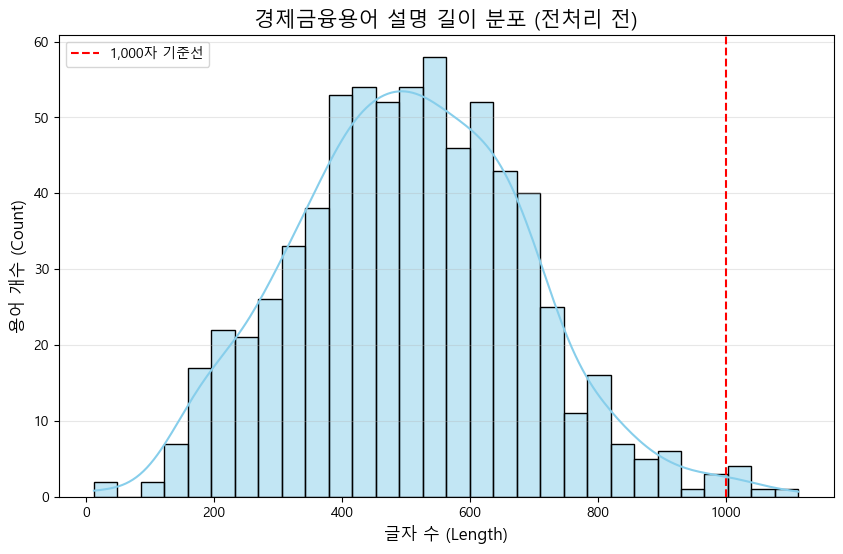


--- [통계 요약] ---
count     700.000000
mean      505.468571
std       180.314438
min        12.000000
25%       383.750000
50%       502.000000
75%       627.250000
max      1113.000000
dtype: float64


In [162]:
# 한글 폰트 설정 (환경에 따라 'AppleGothic' 또는 'NanumGothic' 사용)
font_path = "C:/Windows/Fonts/malgun.ttf"  # Windows
font_name = font_manager.FontProperties(fname=font_path).get_name()
plt.rc('font', family=font_name)

# plt.rcParams['font.family'] = 'NanumGothic' 

# chunk 길이 분포 시각화
plt.figure(figsize=(10, 6))
sns.histplot(raw_chunk_len, bins=30, kde=True, color='skyblue')

plt.title('경제금융용어 설명 길이 분포 (전처리 전)', fontsize=15)
plt.xlabel('글자 수 (Length)', fontsize=12)
plt.ylabel('용어 개수 (Count)', fontsize=12)
plt.axvline(x=1000, color='red', linestyle='--', label='1,000자 기준선')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

# 통계치 요약
import pandas as pd
df_len = pd.Series(raw_chunk_len)
print("\n--- [통계 요약] ---")
print(df_len.describe())

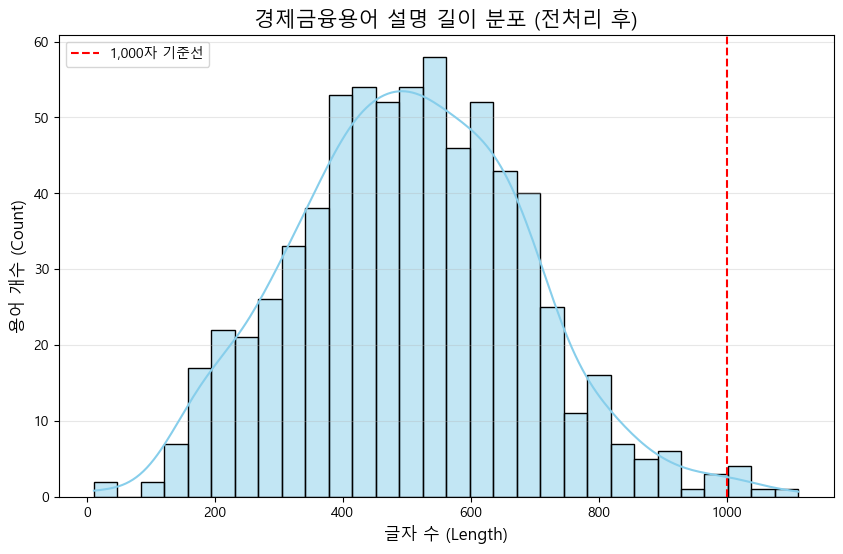


--- [통계 요약] ---
count     700.000000
mean      504.447143
std       180.301461
min        11.000000
25%       382.750000
50%       501.000000
75%       626.250000
max      1112.000000
dtype: float64


In [163]:
# 한글 폰트 설정 (환경에 따라 'AppleGothic' 또는 'NanumGothic' 사용)
font_path = "C:/Windows/Fonts/malgun.ttf"  # Windows
font_name = font_manager.FontProperties(fname=font_path).get_name()
plt.rc('font', family=font_name)

# plt.rcParams['font.family'] = 'NanumGothic' 

# chunk 길이 분포 시각화
plt.figure(figsize=(10, 6))
sns.histplot(final_chunk_len, bins=30, kde=True, color='skyblue')

plt.title('경제금융용어 설명 길이 분포 (전처리 후)', fontsize=15)
plt.xlabel('글자 수 (Length)', fontsize=12)
plt.ylabel('용어 개수 (Count)', fontsize=12)
plt.axvline(x=1000, color='red', linestyle='--', label='1,000자 기준선')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

# 통계치 요약
import pandas as pd
df_len = pd.Series(final_chunk_len)
print("\n--- [통계 요약] ---")
print(df_len.describe())

## 3. 청킹된 문서 품질 검수

In [164]:
# 청킹된 문서를 랜덤으로 샘플링해서 품질 검수
for i in random.sample(range(len(final_chunks)), 30):
    chunk = final_chunks[i]
    print(f"\n--- CHUNK {i} ---")
    print(f"\n용어: {chunk['용어']} (Page: {chunk['metadata']['page']})")
    print(textwrap.fill(chunk['설명'], width=120))


--- CHUNK 431 ---

용어: 유럽연합(EU) (Page: 232)
유럽연합(EU; European Union)은 1991년 12월 유럽공동체 12개국 정상이 유럽연합 조약(일명 마스트리히트조약)의 체결에 합의한 후 1993년 11월 동 조약이 발효됨에 따라 종전의 유럽공동체(EC;
European Communities)를 대신하는 지역공동체로서 1994 년 1월 정식 출범하였다. 창설 목적은 유럽내 단일시장 구축 및 단일통화 실현을 통한 유럽의 경제와 사회발전 촉진, 공동외교안보정책을 통한
국제무대에서의 유럽의 이익 제고, 유럽연합 시민권제도 도입에 의한 회원국 국민의 권리와 이익 보호 등이다. 회원국 은 1995년 1월 3개국이 추가 가입한 데 이어 동유럽 체제전환국들이 가입하면서 점차 늘어나
2017년 10월 현재 총 28개국이다. 유럽연합의 주요 기구는 회원국 정상들의 회의체인 유럽이사회(European Council), 각종 정책 입안 및 집행을 담당하는 집행위원 회(European
Commission), 회원국간 문제해결을 위한 장관들의 회의체인 각료이사회 (CEU), 유럽의회(EP) 등이며 그 외에 유럽사법재판소, 유럽회계감사원, 지역위원회, 유럽중앙은행(ECB), 유럽투자은행 등이 있다.
유럽연합은 유럽의회가 입법부, 유럽사법 재판소가 사법부, 집행위원회가 행정부의 역할을 하는 등 일반적인 국제기구와는 달리 독자적인 법령 체계와 입법･사법･행정 기능을 갖추고 있다.

--- CHUNK 335 ---

용어: 스왑레이트 (Page: 185)
외환스왑시장의 가격변수인 스왑레이트(swap rate)는 현물환율 대비 선물환율과 현물 환율의 차이(=(선물환율-현물환율)/현물환율)를 연율(%)로 표시한 것으로 이론적으로 는 양 통화 간 금리차와
일치(covered interest rate parity)하게 된다. 스왑레이트는 금융기관의 자금사정을 나타내는 대용지표(proxy)로도 활용된다. 예를 들어 국내 금융 기관의 외화자금사정이 악화되면 금

## 4. Export in json format

In [174]:
for i, chunk in enumerate(final_chunks):
    chunk_id = f"econ_{i+1:04d}"
    final_chunks[i] = {'chunk_id': chunk_id, **chunk}
    
    # metadata 처리
    if not final_chunks[i]["metadata"]["연관검색어"]:
        final_chunks[i]["metadata"]["연관검색어"] = "없음"

In [175]:
with open (file_path + 'final_chunk.json', 'w', encoding='utf-8') as f:
    json.dump(final_chunks, f, ensure_ascii=False, indent=4)